## Propensity Score Matching                                                                                                                                                                 
                                                                                                                                                                                            
Replicates the first-stage matching procedure from Mamkhezri, Sun & Yang (2026).                                                                                                             
                                                                                                                                                                                            
**Approach:**                                                                                                                                                                                
1. Restrict sample to census tracts that have at least one LMP pricing node (tracts without observable electricity prices cannot be used in DiD)
2. Define treatment: census tract has at least one data center with first entry between 2017–2025 (excludes always-treated and not-yet-treated units)                                        
3. Exclude tracts that ever had a data center (any year) from the control pool                                                                                                               
4. Estimate propensity scores via probit model using pre-treatment ACS demographics                                                                                                          
5. Exclude treated tracts outside common support                                                                                                                                             
6. Match each treated tract to its 10 nearest untreated neighbors (10-NN with replacement)                                                                                                   
7. Check covariate balance before and after matching                                                                                                                                         
                
**Covariates:**                                                                                                                                                    
- Population    
- % White residents                                                                                                                                                                          
- % High school graduates
- Median household income                                                                                                                                                                    
- Number of housing units
                                                                                                                                                                                            
**Output:** `va_matched_tracts.csv` —  with propensity scores and group assignment                                                                            



In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import statsmodels.api as sm
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = next(
    p / "data" for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "data").exists()
)

lmp_processed_dir = DATA_DIR / "processed" / "preprocessing" / "lmp_data"
analysis_dir = DATA_DIR / "processed" / "for_analysis"
matching_dir = DATA_DIR / "processed" / "preprocessing" / "pre_analysis"

In [2]:
# Load ACS demographic data
acs = pd.read_csv(matching_dir / "va_acs_2016_tract.csv", dtype={"GEOID": str})
n_acs = len(acs)  # store before any filtering    
print("ACS shape:", acs.shape)

# Load data center file
dc = pd.read_excel(analysis_dir / "datacenters_matched_tracts.xlsx",
                   dtype={"census_tract_geoid": str})
print("Data centers shape:", dc.shape)
print("\nData center columns:", dc.columns.tolist())

ACS shape: (1866, 10)
Data centers shape: (292, 43)

Data center columns: ['id', 'state_im3', 'state_abb', 'state_id', 'county', 'county_id', 'operator', 'ref', 'name', 'sqft', 'lon', 'lat', 'type', 'im3_id', 'fractracker_facility_name', 'fractracker_address', 'fractracker_city', 'zip', 'fractracker_county', 'fractracker_lat', 'fractracker_lon', 'fractracker_status', 'fractracker_location_confidence', 'fractracker_operator_name', 'fractracker_mw', 'sizerank', 'facility_size_sqft', 'property_size_acres', 'other_info', 'information_source', 'fractracker_id', 'match_distance_m', 'matched_flag', 'match_quality', 'name_similarity', 'source_year_found', 'year_basis_used', 'year_source_link', 'census_tract_geoid', 'census_tract_name', 'census_statefp', 'census_countyfp', 'census_tractce']


In [3]:
# Restrict ACS to only tracts that have at least one LMP pricing node
# Tracts without pnodes have no observable electricity prices and cannot be used in DiD
lmp = pd.read_csv(lmp_processed_dir / "va_lmp_yearly_avg_load_geo.csv", dtype={"census_geoid": str})
tracts_with_lmp = set(lmp["census_geoid"].dropna().unique())

acs = acs[acs["GEOID"].isin(tracts_with_lmp)].copy()                                                                                                                  
print(f"ACS tracts after restricting to tracts with LMP data: {len(acs)}")
print(f"  (dropped {n_acs - len(acs)} tracts with no pricing nodes)")


ACS tracts after restricting to tracts with LMP data: 350
  (dropped 1516 tracts with no pricing nodes)


In [4]:
# Tracts with LMP data but no ACS data — these are dropped from the analysis, check them
lmp_geoids = set(lmp["census_geoid"].unique())
acs_geoids = set(acs["GEOID"].unique())
missing_from_acs = lmp_geoids - acs_geoids

print(f"Tracts with LMP data but no ACS data (dropped): {len(missing_from_acs)}")
dropped = lmp[lmp["census_geoid"].isin(missing_from_acs)][["census_geoid", "census_name"]].drop_duplicates()
print(dropped.to_string())

Tracts with LMP data but no ACS data (dropped): 5
    census_geoid  census_name
216  51135980100       9801.0
416  51059980300       9803.0
429  51059980200       9802.0
511  51013980100       9801.0
664  51670980100       9801.0


These counties all have population = 0 (checked by manually confirming on census website). Therefore they have no ACS data that can be used for matching. 

In [5]:
# Compute first data center entry year per tract                                                                                                                                       
first_entry = (                                                                                                                                                                        
    dc.dropna(subset=["census_tract_geoid", "source_year_found"])                                                                                                                          
    .groupby("census_tract_geoid")["source_year_found"]                                                                                                                                    
    .min()      
    .reset_index()                                                                                                                                                                     
    .rename(columns={"census_tract_geoid": "census_geoid", "source_year_found": "first_entry_year"})
)                                                                                                                                                                                      
                
print("First entry year distribution:")
print(first_entry["first_entry_year"].value_counts().sort_index())

First entry year distribution:
first_entry_year
1992    1
1998    1
1999    1
2000    4
2001    1
2002    2
2004    1
2006    2
2009    2
2010    1
2011    1
2012    1
2013    1
2015    1
2016    1
2017    6
2018    1
2019    3
2020    1
2021    2
2022    2
2023    2
2024    3
Name: count, dtype: int64


In [6]:
# Create treatment indicator: 1 if tract has at least one data center
treated_geoids = set(dc["census_tract_geoid"].dropna().unique())
print(f"Treated tracts (with data centers): {len(treated_geoids)}")

acs["treated"] = acs["GEOID"].isin(treated_geoids).astype(int)
print(f"Treated in ACS: {acs['treated'].sum()}")
print(f"Untreated in ACS: {(acs['treated'] == 0).sum()}")

print("ACS GEOID sample:", acs["GEOID"].head(3).tolist())
print("DC GEOID sample:", dc["census_tract_geoid"].dropna().head(3).tolist())
print("\nACS GEOID dtype:", acs["GEOID"].dtype)
print("DC GEOID dtype:", dc["census_tract_geoid"].dtype)

Treated tracts (with data centers): 41
Treated in ACS: 19
Untreated in ACS: 331
ACS GEOID sample: ['51550021403', '51003011400', '51081880200']
DC GEOID sample: ['51087201404', '51153901503', '51153901408']

ACS GEOID dtype: str
DC GEOID dtype: str


In [7]:
# Restrict treated group to tracts with first entry 2017-2025
# (excludes always-treated and not-yet-treated units)
valid_treated_geoids = first_entry[                                                                                                                                                    
    (first_entry["first_entry_year"] >= 2017) &
    (first_entry["first_entry_year"] <= 2025)                                                                                                                                          
]["census_geoid"]
                                                                                                                                                                                        
acs["treated"] = acs["GEOID"].isin(valid_treated_geoids).astype(int)                                                                                                                   

print(f"Treated (first DC 2017-2025): {acs['treated'].sum()}")                                                                                                                         
print(f"Untreated: {(acs['treated'] == 0).sum()}")
print(f"Total: {len(acs)}") 

# Tracts that were dropped by year filter                                                                                                             
dropped = first_entry[first_entry["census_geoid"].isin(                                                                                                                                
    set(dc["census_tract_geoid"].dropna().unique()) - set(valid_treated_geoids)
)]                                   
print(f"Tracts that were dropped:")                                                                                                                                                  
print(dropped.sort_values("first_entry_year"))

Treated (first DC 2017-2025): 11
Untreated: 339
Total: 350
Tracts that were dropped:
   census_geoid  first_entry_year
1   51059460501              1992
17  51107611006              1998
25  51107611700              1999
3   51059471201              2000
23  51107611502              2000
22  51107611501              2000
21  51107611020              2000
6   51059481900              2001
2   51059460502              2002
35  51153901410              2002
36  51153901503              2004
8   51059490103              2006
5   51059481202              2006
20  51107611019              2009
0   51047930400              2009
18  51107611015              2010
13  51087200904              2011
33  51153901408              2012
30  51117930600              2013
14  51087201404              2015
9   51059980100              2016


In [8]:
# Exclude always-treated tracts from control pool
ever_treated_geoids = set(dc["census_tract_geoid"].dropna().unique())
                                                                                                                                                                                        
n_removed = ((acs["treated"] == 0) & (acs["GEOID"].isin(ever_treated_geoids))).sum()                                                                                                   
acs = acs[~((acs["treated"] == 0) & (acs["GEOID"].isin(ever_treated_geoids)))].copy()                                                                                                  
                                                                                                                                                                                                                                                                                                  
print(f"Treated: {acs['treated'].sum()} | Untreated: {(acs['treated'] == 0).sum()}")
print(f"Total: {len(acs)}") 
print(f"Removed {n_removed} always-treated tracts from control pool")  

Treated: 11 | Untreated: 331
Total: 342
Removed 8 always-treated tracts from control pool


In [9]:
# Diagnostic check for all census tracts whose earliest recorded data center entry falls within the 2017–2025                                                                                                     
# treatment window — these are candidates for the treated group before the ACS/LMP                                                                                                           
# restriction is applied. Not all will appear in the final treated group: tracts without                                                                                                     
# a PJM pricing node in their boundary were already dropped from the ACS sample                                                                                                                                                        
print(first_entry[first_entry["first_entry_year"].between(2017, 2025)].sort_values("first_entry_year"))  

   census_geoid  first_entry_year
4   51059480902              2017
10  51061930302              2017
11  51061930401              2017
34  51153901409              2017
32  51153901304              2017
19  51107611018              2017
39  51660000402              2018
7   51059482501              2019
12  51069050700              2019
27  51107611804              2019
29  51107611900              2020
31  51153901303              2021
40  51683910402              2021
16  51107611004              2022
26  51107611801              2022
38  51153901509              2023
28  51107611806              2023
24  51107611601              2024
15  51107610604              2024
37  51153901507              2024


In [10]:
# Diagnositic check to identify treated-window tracts that are silently dropped because they have no LMP
# pricing node within their census tract boundary. valid_treated_geoids contains all
# tracts with first DC entry 2017–2025; acs at this point has already been restricted                                                                                                        
# to tracts with at least one pnode. The difference is tracts that qualify on the DC                                                                                                         
# criterion but have no observable electricity price and therefore cannot enter the DiD. 

valid_set = set(valid_treated_geoids)
acs_set = set(acs["GEOID"])  # already restricted to LMP tracts at this point                                                                                                                
                                                                                                                                                                                            
not_in_acs = valid_set - acs_set                                                                                                                                                             
print(f"In DC window but dropped (no LMP data): {len(not_in_acs)}")                                                                                                                          
print(not_in_acs) 

In DC window but dropped (no LMP data): 9
{'51061930302', '51107610604', '51061930401', '51059480902', '51660000402', '51153901507', '51069050700', '51107611900', '51153901509'}


Of the 20 census tracts with a first data center entry between 2017 and 2025, 9 have no PJM pricing node within their tract boundary and were therefore excluded from the ACS sample in the first step. The remaining 11 tracts form the treated group. 

Always-treated tracts (data centre entry before 2017) are excluded from the control group. 

27 data centres are excluded from our full data centre dataset as we could not verify the year of entry. We need to ensure that census tracts that contain at least one of these 27 data centres, and no other data centres, are not used as control tracts. 

In [11]:
# Load PNNL file and identify unverified DCs (those not in datacenters_matched_tracts)                                                                         
import geopandas as gpd                                                                                                                                        
                                                                                                                                                                
pnnl_dir = DATA_DIR / "raw" / "im3_years"                                                                                                                      
pnnl = pd.read_excel(pnnl_dir / "va_pnnl_researched_years_verified.xlsx")                                                                                      
                                                                                                                                                                
pnnl_ids = set(pnnl["id"].dropna())                                                                                                                            
dc_ids = set(dc["id"].dropna())                                                                                                                                
unverified = pnnl[pnnl["id"].isin(pnnl_ids - dc_ids)].dropna(subset=["lat", "lon"]).copy()                                                                                                                                                     
                                                                                                                                                                
# Spatially join unverified DCs to census tracts                                                                                                               
unverified_geo = gpd.GeoDataFrame(                                                                                                                             
    unverified,                                                                                                                                                
    geometry=gpd.points_from_xy(unverified["lon"], unverified["lat"]),                                                                                         
    crs="EPSG:4326"                                                                                                                                            
)
                                                                                                                                                                
census_shp = gpd.read_file(                                                                                                                                    
    DATA_DIR / "raw" / "census_data" / "tl_2016_51_tract" / "tl_2016_51_tract.shp"
).to_crs("EPSG:4326")                                                                                                                                          
                
joined = gpd.sjoin(                                                                                                                                            
    unverified_geo,
    census_shp[["GEOID", "geometry"]],                                                                                                                         
    how="left",
    predicate="within"                                                                                                                                         
)               

# Tracts with ONLY unverified DCs (no verified DCs) that also have LMP data                                                                                    
unverified_tracts = set(joined["GEOID"].dropna().unique())
verified_tracts = set(dc["census_tract_geoid"].dropna().astype(str).unique())                                                                                  
exclusively_unverified = (unverified_tracts - verified_tracts) & tracts_with_lmp                                                                               
                                                                                                                                                                
print(f"Tracts with LMP data whose only DCs are unverified: {len(exclusively_unverified)}")                                                                    
for tract in sorted(exclusively_unverified):                                                                                                                   
    dcs = joined[joined["GEOID"] == tract][["id", "name", "source_year_found", "verified"]]                                                                    
    print(f"\nTract {tract}:")                                                                                                                                 
    print(dcs.to_string())                                                                                                                                     
                                                                                                                                                                                                                                                                          

Tracts with LMP data whose only DCs are unverified: 1

Tract 51107611024:
             id                     name  source_year_found          verified
169   909455922     42310 THUNDERBALL DR                NaN  Could not verify
273  1292897241     42311 THUNDERBALL DR                NaN  Could not verify
274  1292897242     42255 THUNDERBALL DR                NaN  Could not verify
275  1292897243     42254 THUNDERBALL DR                NaN  Could not verify
296  1387391200  True North Data Centers                NaN  Could not verify
297  1387391201       TikTok Data Center                NaN  Could not verify


In [12]:
# Exclude tracts with exclusively unverified DCs from the control pool      
# Tract 51107611024 contains 6 unverified DCs (all estimated 2027) and cannot be                                                                               
# confirmed as clean — excluded as a precaution prior to matching                                                                                    
n_before = len(acs)                                                                                                                                            
acs = acs[~((acs["treated"] == 0) & (acs["GEOID"].isin(exclusively_unverified)))].copy()                                                                       
print(f"Excluded {n_before - len(acs)} tract(s) with exclusively unverified DCs from control pool")                                                            
print(f"Excluded GEOIDs: {exclusively_unverified}")                                                                                                            
print(f"Remaining: {len(acs)} tracts | Treated: {acs['treated'].sum()} | Untreated: {(acs['treated'] == 0).sum()}")  

Excluded 1 tract(s) with exclusively unverified DCs from control pool
Excluded GEOIDs: {'51107611024'}
Remaining: 341 tracts | Treated: 11 | Untreated: 330


Additionally, we identify one treated tract that contains no pre-treatment LMP data, ie. LMP data is only available for the years after treatment. We therefore also drop this tract. 

In [13]:
# Check LMP coverage per treated tract to identify those with no pre-treatment observations                                                                    
# A treated tract with no pre-treatment LMP data cannot contribute to DiD estimation  

lmp_check = pd.read_csv(lmp_processed_dir / "va_lmp_yearly_avg_load_geo.csv", dtype={"census_geoid": str})                                                     
                                                                                                                                                                
# Only check tracts currently in acs with treated == 1 (after all previous filters)                                                                            
treated_geoids_list = acs[acs["treated"] == 1]["GEOID"].tolist()                                                                                               
                                                                                                                                                                
no_pretreat = []
for geoid in treated_geoids_list:
    first_year = first_entry.loc[first_entry["census_geoid"] == geoid, "first_entry_year"].values
    if len(first_year) == 0:                                                                                                                                   
        continue
    pre_lmp = lmp_check[(lmp_check["census_geoid"] == geoid) & (lmp_check["year"] < first_year[0])]                                                            
    if len(pre_lmp) == 0:                                                                                                                                      
        no_pretreat.append(geoid)
                                                                                                                                                                
print(f"Treated tracts with no pre-treatment LMP data: {no_pretreat}")
                                                                                                                                                                
acs = acs[~acs["GEOID"].isin(no_pretreat)].copy()                                                                                                              
print(f"Remaining: {len(acs)} | Treated: {acs['treated'].sum()} | Untreated: {(acs['treated'] == 0).sum()}")

Treated tracts with no pre-treatment LMP data: ['51153901303']
Remaining: 340 | Treated: 10 | Untreated: 330


This results in a final pool of 10 treated tracts, and 330 potential control tracts.

## Propensity Score Matching

In [15]:
# Define covariates for probit model (matching the paper's specification)                                                                                                              
covariates = [                                                                                                                                                                         
    "total_population",                                                                                                                                                                
    "pct_white",                                                                                                                                                                       
    "pct_hs_or_above",
    "median_household_income",                                                                                                                                                         
    "total_housing_units",
]                                                                                                                                                                                      
                                                                                                                                                                                        
# Drop rows with missing values in covariates or outcome
df = acs[["GEOID", "NAME", "treated"] + covariates].dropna()                                                                                                                           
print(f"Rows after dropping NaN: {len(df)} (dropped {len(acs) - len(df)})")                                                                                                            
print(f"Treated: {df['treated'].sum()} | Untreated: {(df['treated'] == 0).sum()}") 

Rows after dropping NaN: 340 (dropped 0)
Treated: 10 | Untreated: 330


In [16]:
# Helper functions for covariate balance assessment                                                                                                                   
# standardized_diff: unweighted, used for pre-matching comparisons                                                                                                    
# standardized_diff_weighted: applies inverse-frequency matching weights to the control group,                                                                        
# so that control tracts matched to multiple treated units do not dominate the balance check  
def standardized_diff(treated_vals, control_vals):                                                                                                                    
    mean_t = treated_vals.mean()
    mean_c = control_vals.mean()                                                                                                                                      
    var_t = treated_vals.var()
    var_c = control_vals.var()                                                                                                                                        
    pooled_std = np.sqrt((var_t + var_c) / 2)
    return (mean_t - mean_c) / pooled_std if pooled_std > 0 else np.nan                                                                                               

def weighted_mean(vals, weights):                                                                                                                                     
    return np.average(vals, weights=weights)
                                                                                                                                                                    
def weighted_var(vals, weights):
    mean = weighted_mean(vals, weights)                                                                                                                               
    return np.average((vals - mean)**2, weights=weights)

def standardized_diff_weighted(treated_vals, control_vals, control_weights):                                                                                          
    mean_t = treated_vals.mean()
    mean_c = weighted_mean(control_vals, control_weights)                                                                                                             
    var_t = treated_vals.var()
    var_c = weighted_var(control_vals, control_weights)                                                                                                               
    pooled_std = np.sqrt((var_t + var_c) / 2)
    return (mean_t - mean_c) / pooled_std if pooled_std > 0 else np.nan                                                                                               
                                                                        

In [17]:
# Estimate propensity scores via probit model
X = sm.add_constant(df[covariates])
y = df["treated"]

probit_model = sm.Probit(y, X).fit()
print(probit_model.summary())

df["propensity_score"] = probit_model.predict(X)

Optimization terminated successfully.
         Current function value: 0.096093
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:                treated   No. Observations:                  340
Model:                         Probit   Df Residuals:                      334
Method:                           MLE   Df Model:                            5
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                  0.2758
Time:                        16:56:48   Log-Likelihood:                -32.672
converged:                       True   LL-Null:                       -45.115
Covariance Type:            nonrobust   LLR p-value:                 0.0001465
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -3.5041      2.882     -1.216      0.224      -9.152   

In [18]:
# Split into treated and untreated groups based on treatment indicator
treated_unlog = df[df["treated"] == 1].copy()
untreated_unlog = df[df["treated"] == 0].copy()                                                                                                                       

# Common support check: exclude treated tracts whose propensity score exceeds                                                                                         
# the maximum propensity score among untreated tracts — these have no comparable
# control and cannot be matched                                                                                                                                       
max_ps = untreated_unlog["propensity_score"].max()                                                                                                                    
treated_in_support_unlog = treated_unlog[treated_unlog["propensity_score"] <= max_ps]                                                                                 
excluded_unlog = treated_unlog[treated_unlog["propensity_score"] > max_ps]                                                                                            
print(f"Treated in support: {len(treated_in_support_unlog)} | Excluded: {len(excluded_unlog)}")                                                                       
                                                                                                                                                                    
# Fit k-NN model on untreated propensity scores                                                                                                                       
# For each treated tract, find its 10 nearest untreated neighbors by propensity score distance                                                                        
knn_unlog = NearestNeighbors(n_neighbors=10, metric="euclidean")                                                                                                      
knn_unlog.fit(untreated_unlog[["propensity_score"]])
distances, indices = knn_unlog.kneighbors(treated_in_support_unlog[["propensity_score"]])                                                                             
                                                                                                                                                                    
# indices is a (n_treated x 10) array of positions in untreated_unlog                                                                                                 
# flatten to get all matched control positions across all treated tracts                                                                                              
matched_indices = indices.flatten()                                                                                                                                   
                    
# Count how many times each untreated tract was selected as a neighbor                                                                                                
# tracts matched to multiple treated units appear more than once
match_counts = pd.Series(matched_indices).value_counts()                                                                                                              
                                                                                                                                                                    
# Map positional indices back to dataframe index labels                                                                                                               
untreated_idx = untreated_unlog.index.tolist()                                                                                                                        
count_by_idx = {untreated_idx[i]: count for i, count in match_counts.items()}                                                                                         
                
# Keep only the unique untreated tracts that were matched at least once                                                                                               
# Assign inverse-frequency weights: tracts matched more often get lower weight
# so that no single control tract dominates the analysis                                                                                                              
matched_unlog = untreated_unlog[untreated_unlog.index.isin(count_by_idx.keys())].copy()                                                                               
matched_unlog["weight"] = matched_unlog.index.map(lambda i: 1 / count_by_idx[i])                                                                                      
                                                                                                                                                                    
print(f"Unique control tracts: {len(matched_unlog)}")                                                                                                                 
                
# Balance check — standardized differences                                                                                                                            
# Compares treated and control means before and after matching
# Values closer to 0 indicate better balance; conventional threshold is |0.25|                                                                                        
print("\nCovariate Balance (standardized differences):")                                                                                                              
print(f"{'Covariate':<30} {'std_diff_before':>16} {'std_diff_after':>15}")                                                                                            
print("-" * 63)                                                                                                                                                       
for cov in covariates:
    # Before: full unmatched sample
    before = standardized_diff(
        df[df["treated"] == 1][cov],
        df[df["treated"] == 0][cov]
    )
    # After: matched sample with inverse-frequency weights applied to controls
    after = standardized_diff_weighted(                                                                                                                               
        treated_in_support_unlog[cov],
        matched_unlog[cov],                                                                                                                                           
        matched_unlog["weight"]
    )
    print(f"{cov:<30} {before:>16.3f} {after:>15.3f}")

# Balance check — weighted regression
# Regresses each covariate on the treatment indicator using matching weights
# A significant p_after indicates residual imbalance on that covariate                                                                                                
from statsmodels.regression.linear_model import WLS                                                                                                                   
                                                                                                                                                                    
print("\nWeighted regression p-values:")                                                                                                                              
print(f"{'Covariate':<30} {'coef':>10} {'p_before':>10} {'p_after':>10}")
print("-" * 62)                                                                                                                                                       
                
# Combine treated and matched control tracts into one dataframe for regression                                                                                        
all_unlog = pd.concat([
    treated_in_support_unlog.assign(weight=1.0),                                                                                                                      
    matched_unlog
])

for cov in covariates:
    # Before matching: unweighted OLS on full sample
    X_before = sm.add_constant(df["treated"])                                                                                                                         
    p_before = sm.OLS(df[cov], X_before).fit().pvalues["treated"]                                                                                                     
                                                                                                                                                                    
    # After matching: WLS using inverse-frequency matching weights                                                                                                    
    X_after = sm.add_constant(all_unlog["treated"])
    wls = WLS(all_unlog[cov], X_after, weights=all_unlog["weight"]).fit()                                                                                             
    coef = wls.params["treated"]  # weighted mean difference between treated and control                                                                              
    p_after = wls.pvalues["treated"]                                                                                                                                  
                                                                                                                                                                    
    sig_before = "***" if p_before < 0.01 else "**" if p_before < 0.05 else "*" if p_before < 0.1 else ""                                                             
    sig_after = "***" if p_after < 0.01 else "**" if p_after < 0.05 else "*" if p_after < 0.1 else ""
    print(f"{cov:<30} {coef:>10.3f} {p_before:>9.3f}{sig_before:>1} {p_after:>9.3f}{sig_after:>1}")                                                                   
                                                                                                                                                                    
print("\n* p<0.10  ** p<0.05  *** p<0.01")                                                                                                                            
                                            

Treated in support: 10 | Excluded: 0
Unique control tracts: 60

Covariate Balance (standardized differences):
Covariate                       std_diff_before  std_diff_after
---------------------------------------------------------------
total_population                          0.653           0.475
pct_white                                -0.668          -0.071
pct_hs_or_above                           1.035           0.385
median_household_income                   1.801           0.639
total_housing_units                       0.062           0.257

Weighted regression p-values:
Covariate                            coef   p_before    p_after
--------------------------------------------------------------
total_population                 1125.203     0.017**     0.115 
pct_white                          -1.306     0.072*     0.845 
pct_hs_or_above                     1.917     0.013**     0.309 
median_household_income         24286.997     0.000***     0.096*
total_housing_units     

The weighted regression for each covariate is:                                                                                                                        
                                                                                                                                                                        
  $$X_i = \alpha + \beta \cdot \text{treated}_i + \varepsilon_i$$                                                                                                       
                                                                                                                                                                        
  where observations are weighted by $w_i$, minimising:                                                                                                                 
                                                                                                                                                                        
  $$\sum_i w_i (X_i - \alpha - \beta \cdot \text{treated}_i)^2$$                                                                                                        
                                                                                                                                                                        
  where:                                                                                                                                                              
  - $X_i$ is the covariate value for tract $i$ (e.g. median income)                                                                                                     
  - $\text{treated}_i$ is 1 for treated tracts, 0 for controls                                                                                                        
  - $w_i = 1$ for treated tracts, $w_i = 1/\text{match count}$ for control tracts                                                                                       
  - $\beta$ is the weighted difference in means between treated and control — this is the coefficient shown in the output                                             
  - The p-value on $\beta$ tests whether that difference is statistically distinguishable from zero                                                                     
                                                                                                   
  If matching achieved perfect balance, $\beta$ would be zero for every covariate. 

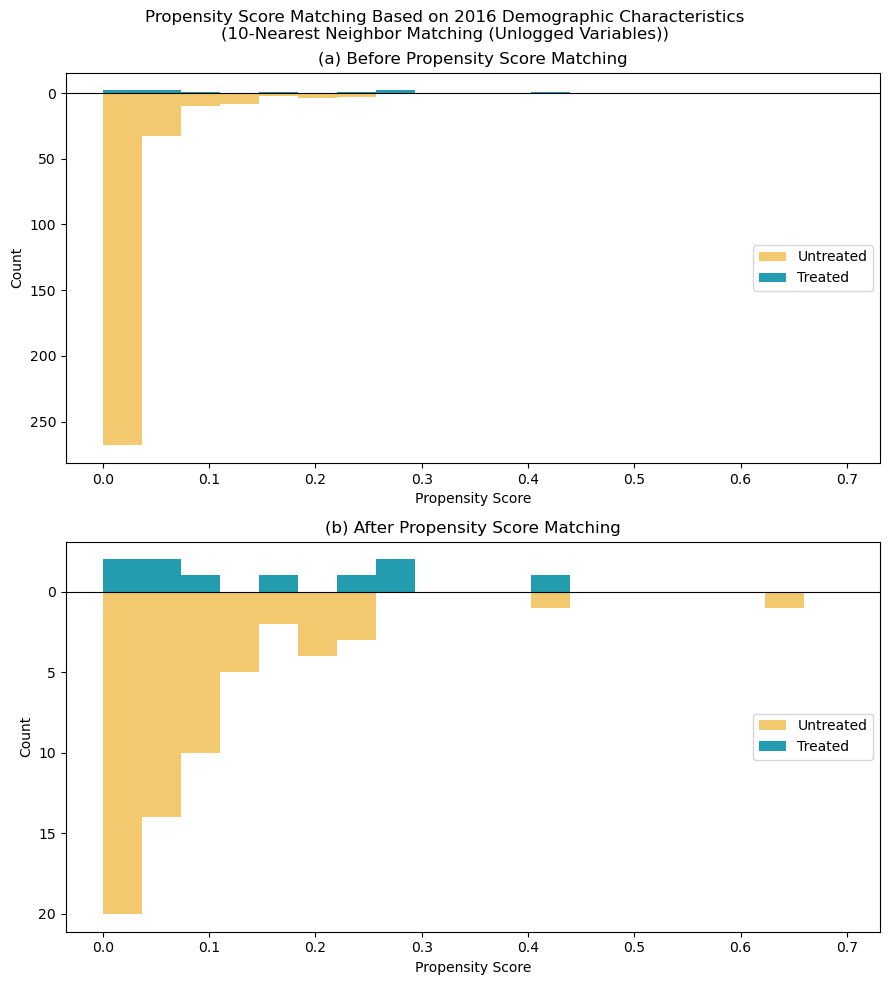

In [65]:
#Plot propensity score distributions before and after matching - unlogged                                                                                             
fig, axes = plt.subplots(2, 1, figsize=(9, 10))                                                                                                                       
                                                                                                                                                                
bins = np.linspace(0, df["propensity_score"].max() + 0.05, 20)                                                                                                        
                                                                                                                                                                
# --- Panel (a): Before matching ---                                                                                                                                  
ax = axes[0]    
                                                                                                                                                                
untreated_ps = df[df["treated"] == 0]["propensity_score"]
treated_on_ps = treated_in_support_unlog["propensity_score"]                                                                                                          
treated_off_ps = excluded_unlog["propensity_score"]                                                                                                                   

ax.hist(untreated_ps, bins=bins, color="#f2c45f", alpha=0.9, label="Untreated",                                                                                     
        weights=np.ones(len(untreated_ps)) * -1)
ax.hist(treated_on_ps, bins=bins, color="#0B91A7", alpha=0.9, label="Treated")                                                                            
if len(treated_off_ps) > 0:                                                                                                                                           
        ax.hist(treated_off_ps, bins=bins, color="mediumseagreen", alpha=0.9, label="Treated: Off support")                                                               
                                                                                                                                                                
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Propensity Score")                                                                                                                                     
ax.set_ylabel("Count")                                                                                                                                                
ax.set_title("(a) Before Propensity Score Matching")
ax.legend(loc="right")                                                                                                                                                
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(abs(x)))))                                                                                        

# --- Panel (b): After matching ---                                                                                                                                   
ax = axes[1]    
                                                                                                                                                                
bins2 = np.linspace(0, max(treated_in_support_unlog["propensity_score"].max(),
                        matched_unlog["propensity_score"].max()) + 0.05, 20)
                                                                                                                                                                
control_ps = matched_unlog["propensity_score"]
                                                                                                                                                                
ax.hist(control_ps, bins=bins2, color="#f2c45f", alpha=0.9, label="Untreated",                                                                                      
        weights=np.ones(len(control_ps)) * -1)
ax.hist(treated_in_support_unlog["propensity_score"], bins=bins2, color="#0B91A7", alpha=0.9, label="Treated")                                                        
                                                                                                                                                                
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Propensity Score")                                                                                                                                     
ax.set_ylabel("Count")                                                                                                                                                
ax.set_title("(b) After Propensity Score Matching")
ax.legend(loc="right")                                                                                                                                                
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(abs(x)))))
                                                                                                                                                                
fig.suptitle("Propensity Score Matching Based on 2016 Demographic Characteristics\n(10-Nearest Neighbor Matching (Unlogged Variables))",                                                   
        fontsize=12)                                                                                                                                              
plt.tight_layout()                                                                                                                                                    
plt.show()  

fig.savefig(Path.cwd().parents[1] / "output/figures/psm_unlogged.png", dpi=300, bbox_inches="tight")  

In the balance checks, for 10-NN unlogged, income has a standardized difference of 0.639 after matching and a statistically significant p-value of 0.096. This means that even after matching, the  control tracts are lower-income than the treated tracts. Try again with logged variables.
Note: pct_white and pct_hs_or_above are not logged since they are percentages bounded between 0 and 100.     

In [22]:
# Create logged versions of skewed covariates   
df_log = df.copy()                                                                                                                                                    
df_log["log_total_population"] = np.log(df_log["total_population"])                                                                                                   
df_log["log_median_household_income"] = np.log(df_log["median_household_income"])                                                                                     
df_log["log_total_housing_units"] = np.log(df_log["total_housing_units"])                                                                                      
                                                                                                                                                                    
covariates_log = [
    "log_total_population",                                                                                                                                           
    "pct_white",
    "pct_hs_or_above",
    "log_median_household_income",                                                                                                                                    
    "log_total_housing_units",
]                                                                                                                                                                     
                
# Re-estimate probit with logged covariates                                                                                                                           
X_log = sm.add_constant(df_log[covariates_log])
y_log = df_log["treated"]                                                                                                                                             
probit_log = sm.Probit(y_log, X_log).fit()                                                                                                                            
print(probit_log.summary())
df_log["propensity_score"] = probit_log.predict(X_log)                                                                                                                           
                                            

Optimization terminated successfully.
         Current function value: 0.088907
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:                treated   No. Observations:                  340
Model:                         Probit   Df Residuals:                      334
Method:                           MLE   Df Model:                            5
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                  0.3300
Time:                        16:58:28   Log-Likelihood:                -30.228
converged:                       True   LL-Null:                       -45.115
Covariance Type:            nonrobust   LLR p-value:                 1.634e-05
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                         -22.8403      5.843     -3.909      0.000   

In [ ]:
#Export to Latex (couldnt find a package, done kind of inefficientlyly with formatting outlined manually)
probit_labels = {                                                                                                                                              
    "const": "Constant",                                                                                                                                       
    "log_total_population": "Log total population",                                                                                                            
    "pct_white": "Proportion white",                                                                                                                           
    "pct_hs_or_above": "Proportion HS or above",                                                                                                               
    "log_median_household_income": "Log median household income",                                                                                              
    "log_total_housing_units": "Log total housing units",
}                                                                                                                                                              
                
rows_probit = []                                                                                                                                               
for var in probit_log.params.index:
    label = probit_labels.get(var, var)                                                                                                                        
    coef = probit_log.params[var]
    se = probit_log.bse[var]                                                                                                                                   
    p = probit_log.pvalues[var]
    sig = "^{***}" if p < 0.01 else "^{**}" if p < 0.05 else "^{*}" if p < 0.1 else ""                                                                         
    rows_probit.append(f"    {label:<35} & {coef:>7.3f}${sig}$ & {se:>7.3f} & {p:>7.3f} \\\\")                                                                 
                                                                                                                                                                
probit_body = "\n".join(rows_probit)                                                                                                                           
                                                                                                                                                                
latex_probit = f"""\\begin{{table}}[htbp]                                                                                                                      
\\centering     
\\caption{{Probit Model: Propensity Score Estimation}}
\\label{{tab:probit}}                                                                                                                                          
\\begin{{tabular}}{{lccc}}
\\hline\\hline                                                                                                                                                 
\\textbf{{Covariate}} & \\textbf{{Coefficient}} & \\textbf{{Std. Error}} & \\textbf{{p-value}} \\\\
\\hline                                                                                                                                                        
{probit_body}
\\hline                                                                                                                                                        
Observations & \\multicolumn{{3}}{{c}}{{{int(probit_log.nobs)}}} \\\\
Pseudo $R^2$ & \\multicolumn{{3}}{{c}}{{{probit_log.prsquared:.3f}}} \\\\                                                                                      
\\hline\\hline                                                                                                                                                 
\\end{{tabular}}                                                                                                                                               
\\vspace{{0.5em}}                                                                                                                                              
\\begin{{minipage}}{{\\textwidth}}
\\footnotesize                                                                                                                                                 
\\textit{{Notes:}} Probit model estimated on logged covariates. $^{{*}}p<0.10$, $^{{**}}p<0.05$, $^{{***}}p<0.01$.
\\end{{minipage}}                                                                                                                                              
\\end{{table}}"""
                                                                                                                                                                
with open(Path.cwd().parents[1] / "output/tables/probit_results.tex", "w") as f:
    f.write(latex_probit)                                                                                                                                      
print("Saved probit_results.tex")
                                

Saved probit_results.tex


In [69]:
# Split into treated and untreated groups based on treatment indicator                                                                                                
treated_log = df_log[df_log["treated"] == 1].copy()                                                                                                                   
untreated_log = df_log[df_log["treated"] == 0].copy()                                                                                                                 
                                                                                                                                                                    
# Common support check: exclude treated tracts whose propensity score exceeds                                                                                         
# the maximum propensity score among untreated tracts — these have no comparable                                                                                      
# control and cannot be matched                                                                                                                                       
max_ps = untreated_log["propensity_score"].max()
treated_in_support_log = treated_log[treated_log["propensity_score"] <= max_ps]                                                                                       
excluded_log = treated_log[treated_log["propensity_score"] > max_ps]                                                                                                  
print(f"Treated in support: {len(treated_in_support_log)} | Excluded: {len(excluded_log)}")                                                                           
                                                                                                                                                                    
# Fit k-NN model on untreated propensity scores                                                                                                                       
# For each treated tract, find its 10 nearest untreated neighbors by propensity score distance                                                                        
knn_log = NearestNeighbors(n_neighbors=10, metric="euclidean")                                                                                                        
knn_log.fit(untreated_log[["propensity_score"]])                                                                                                                      
distances, indices = knn_log.kneighbors(treated_in_support_log[["propensity_score"]])                                                                                 
                                                                                                                                                                    
# indices is a (n_treated x 10) array of positions in untreated_log                                                                                                   
# flatten to get all matched control positions across all treated tracts                                                                                              
matched_indices = indices.flatten()                                                                                                                                   
                
# Count how many times each untreated tract was selected as a neighbor                                                                                                
# tracts matched to multiple treated units appear more than once
match_counts = pd.Series(matched_indices).value_counts()                                                                                                              

# Map positional indices back to dataframe index labels                                                                                                               
untreated_idx = untreated_log.index.tolist()
count_by_idx = {untreated_idx[i]: count for i, count in match_counts.items()}
                                                                                                                                                                    
# Keep only the unique untreated tracts that were matched at least once
# Assign inverse-frequency weights: tracts matched more often get lower weight                                                                                        
# so that no single control tract dominates the analysis                                                                                                              
matched_log = untreated_log[untreated_log.index.isin(count_by_idx.keys())].copy()
matched_log["weight"] = matched_log.index.map(lambda i: 1 / count_by_idx[i])                                                                                          
                                                                                                                                                                    
print(f"Unique control tracts: {len(matched_log)}")
                                                                                                                                                                    
# Balance check — standardized differences
# Compares treated and control means before and after matching
# Values closer to 0 indicate better balance; conventional threshold is |0.25|                                                                                        
print("\nCovariate Balance (standardized differences):")
print(f"{'Covariate':<30} {'std_diff_before':>16} {'std_diff_after':>15}")                                                                                            
print("-" * 63)                                                                                                                                                       
for cov in covariates_log:
    # Before: full unmatched sample                                                                                                                                   
    before = standardized_diff(
        df_log[df_log["treated"] == 1][cov],                                                                                                                          
        df_log[df_log["treated"] == 0][cov]
    )                                                                                                                                                                 
    # After: matched sample with inverse-frequency weights applied to controls
    after = standardized_diff_weighted(                                                                                                                               
        treated_in_support_log[cov],
        matched_log[cov],                                                                                                                                             
        matched_log["weight"]
    )
    print(f"{cov:<30} {before:>16.3f} {after:>15.3f}")
                                                                                                                                                                    
# Balance check — weighted regression
# Regresses each covariate on the treatment indicator using matching weights                                                                                          
# A significant p_after indicates residual imbalance on that covariate
from statsmodels.regression.linear_model import WLS                                                                                                                   

print("\nWeighted regression p-values:")                                                                                                                              
print(f"{'Covariate':<30} {'coef':>10} {'p_before':>10} {'p_after':>10}")
print("-" * 62)                                                                                                                                                       

# Combine treated and matched control tracts into one dataframe for regression                                                                                        
all_log = pd.concat([
    treated_in_support_log.assign(weight=1.0),
    matched_log                                                                                                                                                       
])
                                                                                                                                                                    
for cov in covariates_log:
    # Before matching: unweighted OLS on full sample
    X_before = sm.add_constant(df_log["treated"])
    p_before = sm.OLS(df_log[cov], X_before).fit().pvalues["treated"]                                                                                                 

    # After matching: WLS using inverse-frequency matching weights                                                                                                    
    X_after = sm.add_constant(all_log["treated"])
    wls = WLS(all_log[cov], X_after, weights=all_log["weight"]).fit()                                                                                                 
    coef = wls.params["treated"]  # weighted mean difference between treated and control
    p_after = wls.pvalues["treated"]                                                                                                                                  
                
    sig_before = "***" if p_before < 0.01 else "**" if p_before < 0.05 else "*" if p_before < 0.1 else ""                                                             
    sig_after = "***" if p_after < 0.01 else "**" if p_after < 0.05 else "*" if p_after < 0.1 else ""
    print(f"{cov:<30} {coef:>10.3f} {p_before:>9.3f}{sig_before:>1} {p_after:>9.3f}{sig_after:>1}")                                                                   
                                                                                                                                                                    
print("\n* p<0.10  ** p<0.05  *** p<0.01")   

Treated in support: 10 | Excluded: 0
Unique control tracts: 57

Covariate Balance (standardized differences):
Covariate                       std_diff_before  std_diff_after
---------------------------------------------------------------
log_total_population                      0.550           0.406
pct_white                                -0.668          -0.237
pct_hs_or_above                           1.035           0.337
log_median_household_income               1.931           0.566
log_total_housing_units                   0.088           0.294

Weighted regression p-values:
Covariate                            coef   p_before    p_after
--------------------------------------------------------------
log_total_population                0.188     0.059*     0.183 
pct_white                          -4.314     0.072*     0.504 
pct_hs_or_above                     1.627     0.013**     0.357 
log_median_household_income         0.199     0.000***     0.131 
log_total_housing_units  

In [ ]:
#Export these tables as LATEX (couldnt find a package, done kind of inefficientlyly with formatting outlined manually)

covariate_labels = {
    "log_total_population": "Log total population",
    "pct_white": "Proportion white",                                                                                                                           
    "pct_hs_or_above": "Proportion HS or above",
    "log_median_household_income": "Log median household income",                                                                                              
    "log_total_housing_units": "Log total housing units",
}                                                                                                                                                              
                    
rows_std = []                                                                                                                                                  
rows_reg = []
                                                                                                                                                                
for cov in covariates_log:                                                                                                                                     
    label = covariate_labels[cov]
    before_std = standardized_diff(df_log[df_log["treated"]==1][cov], df_log[df_log["treated"]==0][cov])                                                       
    after_std = standardized_diff_weighted(treated_in_support_log[cov], matched_log[cov], matched_log["weight"])                                               
                                                                                                                                                                
    X_before = sm.add_constant(df_log["treated"])                                                                                                              
    p_before = sm.OLS(df_log[cov], X_before).fit().pvalues["treated"]                                                                                          
    X_after = sm.add_constant(all_log["treated"])                                                                                                              
    wls = WLS(all_log[cov], X_after, weights=all_log["weight"]).fit()
    coef = wls.params["treated"]                                                                                                                               
    p_after = wls.pvalues["treated"]
                                                                                                                                                                
    sig_before = "^{***}" if p_before < 0.01 else "^{**}" if p_before < 0.05 else "^{*}" if p_before < 0.1 else ""                                             
    sig_after  = "^{***}" if p_after  < 0.01 else "^{**}" if p_after  < 0.05 else "^{*}" if p_after  < 0.1 else ""                                             
                                                                                                                                                                
    rows_std.append(f"    {label:<35} & {before_std:>7.3f} & {after_std:>7.3f} \\\\")                                                                          
    rows_reg.append(f"    {label:<35} & {coef:>7.3f} & {p_before:.3f}${sig_before}$ & {p_after:.3f}${sig_after}$ \\\\")                                        
                                                                                                                                                                
std_body = "\n".join(rows_std)
reg_body = "\n".join(rows_reg)                                                                                                                                 
                                                                                                                                                                
latex = f"""\\begin{{table}}[htbp]
\\centering                                                                                                                                                    
\\caption{{Covariate Balance}}
\\label{{tab:balance}}

\\begin{{subtable}}{{\\textwidth}}
\\centering                                                                                                                                                    
\\caption{{Standardised Differences}}
\\begin{{tabular}}{{lcc}}                                                                                                                                      
\\hline\\hline  
\\textbf{{Covariate}} & \\textbf{{Before Matching}} & \\textbf{{After Matching}} \\\\
\\hline                                                                                                                                                        
{std_body}
\\hline\\hline                                                                                                                                                 
\\end{{tabular}}
\\end{{subtable}}

\\vspace{{1em}}
                                                                                                                                                                
\\begin{{subtable}}{{\\textwidth}}
\\centering                                                                                                                                                    
\\caption{{Weighted Regression P-values}}
\\begin{{tabular}}{{lccc}}
\\hline\\hline
\\textbf{{Covariate}} & \\textbf{{Coefficient}} & \\textbf{{Before Matching}} & \\textbf{{After Matching}} \\\\
\\hline                                                                                                                                                        
{reg_body}
\\hline\\hline                                                                                                                                                 
\\end{{tabular}}
\\end{{subtable}}                                                                                                                                              

\\vspace{{0.5em}}                                                                                                                                              
\\begin{{minipage}}{{\\textwidth}}
\\footnotesize
\\textit{{Notes:}} Standardised differences are calculated as the difference in covariate means between treated and control tracts, divided by the pooled 
standard deviation. Weighted regression p-values are obtained by regressing each covariate on the treatment indicator, weighted by matching weights.           
$^{{*}}p<0.10$, $^{{**}}p<0.05$, $^{{***}}p<0.01$.
\\end{{minipage}}                                                                                                                                              
                
\\end{{table}}"""

with open(Path.cwd().parents[1] / "output/tables/covariate_balance.tex", "w") as f:                                                                           
    f.write(latex)
print("Saved covariate_balance.tex")                                                                                                                         
                            

Saved covariate_balance.tex


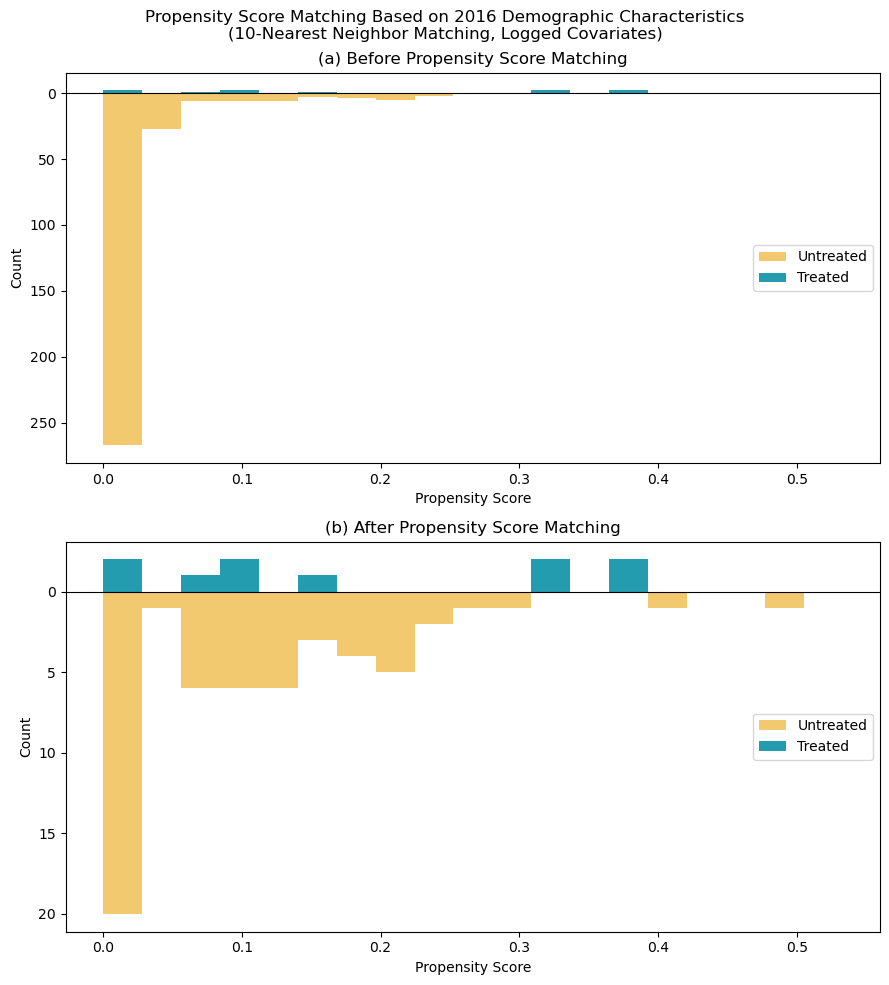

In [66]:
#Plot again with logged variables

fig, axes = plt.subplots(2, 1, figsize=(9, 10))

bins = np.linspace(0, df_log["propensity_score"].max() + 0.05, 20)                                                                                                    

# --- Panel (a): Before matching ---                                                                                                                                  
ax = axes[0]         
                                                                                                                                                                    
untreated_ps = untreated_log["propensity_score"]
treated_on_ps = treated_in_support_log["propensity_score"]
treated_off_ps = excluded_log["propensity_score"]                                                                                                                     

ax.hist(untreated_ps, bins=bins, color="#f2c45f", alpha=0.9, label="Untreated",                                                                                     
        weights=np.ones(len(untreated_ps)) * -1)
ax.hist(treated_on_ps, bins=bins, color="#0B91A7", alpha=0.9, label="Treated")                                                                            
if len(treated_off_ps) > 0:                                                                                                                                           
    ax.hist(treated_off_ps, bins=bins, color="mediumseagreen", alpha=0.9, label="Treated: Off support")
                                                                                                                                                                    
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Propensity Score")                                                                                                                                     
ax.set_ylabel("Count")
ax.set_title("(a) Before Propensity Score Matching")                                                                                                                  
ax.legend(loc="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(abs(x)))))                                                                                        
                                                                                                                                                                    
# --- Panel (b): After matching ---
ax = axes[1]                                                                                                                                                          
                    
bins2 = np.linspace(0, max(treated_in_support_log["propensity_score"].max(),                                                                                          
                            matched_log["propensity_score"].max()) + 0.05, 20)
                                                                                                                                                                    
control_ps = matched_log["propensity_score"]

ax.hist(control_ps, bins=bins2, color="#f2c45f", alpha=0.9, label="Untreated",                                                                                      
        weights=np.ones(len(control_ps)) * -1)
ax.hist(treated_in_support_log["propensity_score"], bins=bins2, color="#0B91A7", alpha=0.9, label="Treated")                                                          
                                                                                                                                                                    
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Propensity Score")                                                                                                                                     
ax.set_ylabel("Count")
ax.set_title("(b) After Propensity Score Matching")                                                                                                                   
ax.legend(loc="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(abs(x)))))                                                                                        
                                                                                                                                                                    
fig.suptitle("Propensity Score Matching Based on 2016 Demographic Characteristics\n(10-Nearest Neighbor Matching, Logged Covariates)",                                
            fontsize=12)                                                                                                                                              
plt.tight_layout()                                                                                                                                                    
plt.show()  

fig.savefig(Path.cwd().parents[1] / "output/figures/psm_logged.png", dpi=300, bbox_inches="tight")  

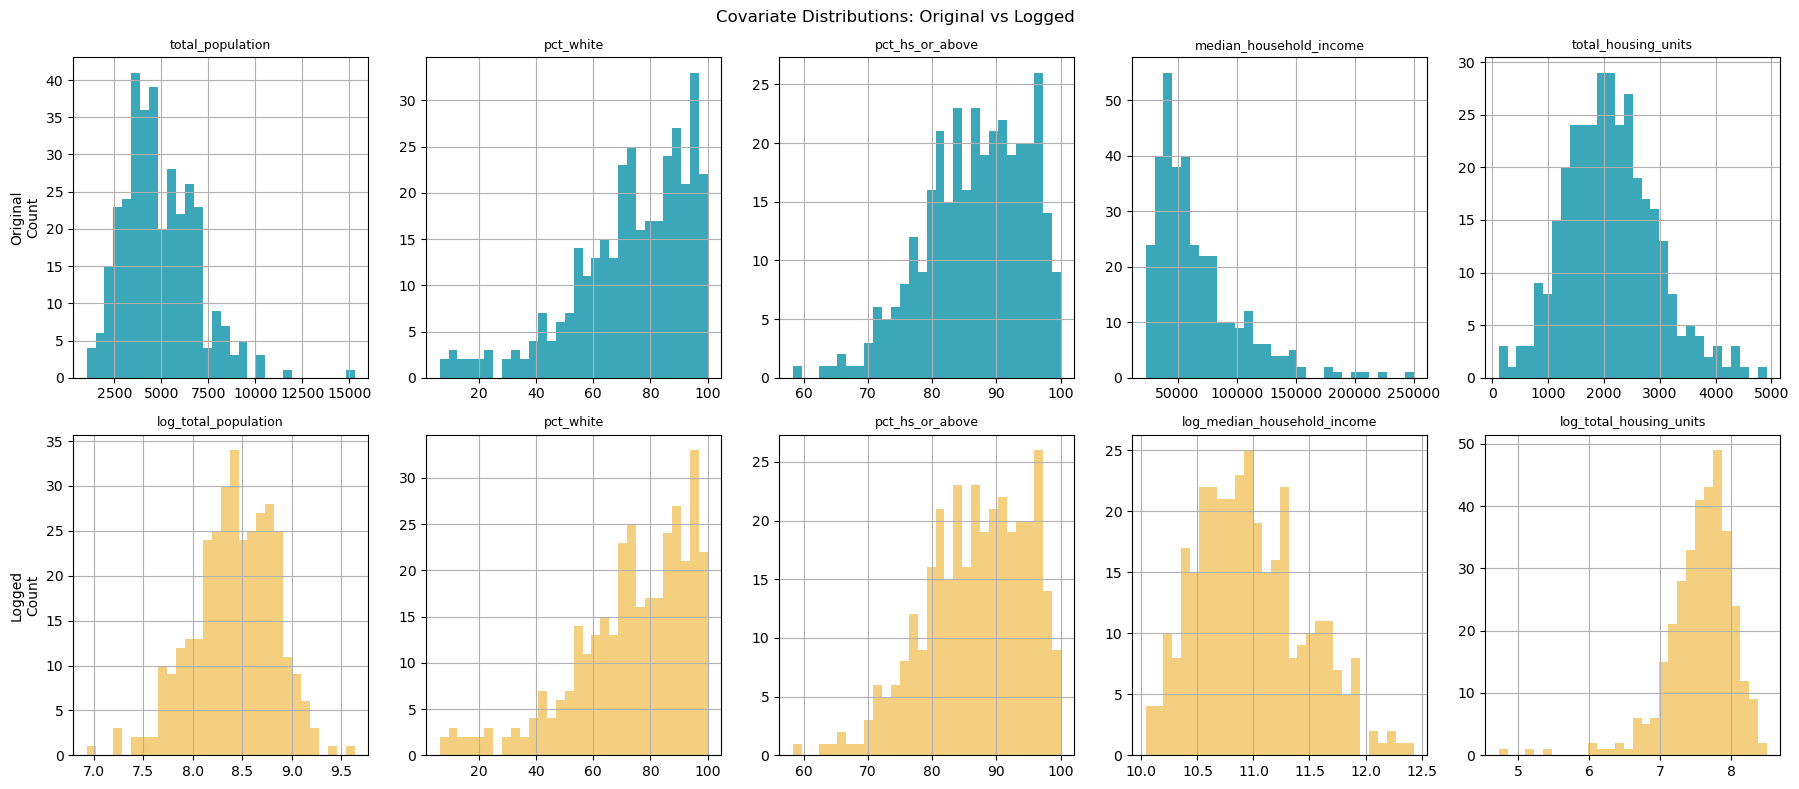

In [67]:
#Plot logged vs unlogged covariate distributions
fig, axes = plt.subplots(2, len(covariates), figsize=(18, 8))                                                                                                         
                                                                                                                                                                    
for i, (cov_orig, cov_log) in enumerate(zip(covariates, covariates_log)):                                                                                             
    # Original                                                                                                                                                        
    df[cov_orig].hist(ax=axes[0, i], bins=30, color="#0B91A7", alpha=0.8)                                                                                           
    axes[0, i].set_title(cov_orig, fontsize=9)                                                                                                                        
    axes[0, i].set_ylabel("Count" if i == 0 else "")                                                                                                                  
                                                                                                                                                                    
    # Logged    
    df_log[cov_log].hist(ax=axes[1, i], bins=30, color="#f2c45f", alpha=0.8)                                                                                          
    axes[1, i].set_title(cov_log, fontsize=9)                                                                                                                         
    axes[1, i].set_ylabel("Count" if i == 0 else "")
                                                                                                                                                                    
axes[0, 0].set_ylabel("Original\nCount")
axes[1, 0].set_ylabel("Logged\nCount")                                                                                                                                
                                                                                                                                                                    
plt.suptitle("Covariate Distributions: Original vs Logged", fontsize=12)
plt.tight_layout()                                                                                                                                                    
plt.show() 

fig.savefig(Path.cwd().parents[1] / "output/figures/log_vs_unlog_covariate_dist.png", dpi=300, bbox_inches="tight") 

We see that the logged version of the k-NN matching achieves better balance across all covariates. There are no statistically significant differences remain between treatment and control groups after matching with the logged variables. We therefore save this version to construct the matched DiD panel. 

In [51]:
# Save matched sample (logged)
matched_sample = pd.concat([
    treated_in_support_log.assign(group="treated", weight=1.0),                                                                                                                   
    matched_log.assign(group="control")
], ignore_index=True)                                                                                                                                                 
                    
matched_sample.to_csv(matching_dir / "va_matched_tracts.csv", index=False)                                                                                            
print(f"Saved {len(matched_sample):,} rows to va_matched_tracts.csv")
print(f"  Treated: {(matched_sample['group'] == 'treated').sum()}")                                                                                                   
print(f"  Control: {(matched_sample['group'] == 'control').sum()}")

Saved 67 rows to va_matched_tracts.csv
  Treated: 10
  Control: 57


## Robustness Checks
Check for different values of k-nn.

In [47]:
# Check for knn sensitivity by comparing balance and unique control counts across k=5, 7, 10 (logged version)
results_log = {}
                                                                                                                                                                    
for k in [5, 7, 10]:
    knn = NearestNeighbors(n_neighbors=k, metric="euclidean")                                                                                                         
    knn.fit(untreated_log[["propensity_score"]])
    distances, indices = knn.kneighbors(treated_in_support_log[["propensity_score"]])                                                                                 

    matched_indices = indices.flatten()                                                                                                                               
    match_counts = pd.Series(matched_indices).value_counts()
                                                                                                                                                                    
    untreated_idx = untreated_log.index.tolist()
    count_by_idx = {untreated_idx[i]: count for i, count in match_counts.items()}                                                                                     
    matched_unique = untreated_log[untreated_log.index.isin(count_by_idx.keys())].copy()                                                                              
    matched_unique["weight"] = matched_unique.index.map(lambda i: 1 / count_by_idx[i])
                                                                                                                                                                    
    balance = {}     
    for cov in covariates_log:                                                                                                                                        
        std_diff_after = standardized_diff_weighted(
            treated_in_support_log[cov],
            matched_unique[cov],                                                                                                                                      
            matched_unique["weight"]
        )                                                                                                                                                             
        balance[cov] = round(std_diff_after, 3)

    results_log[k] = {                                                                                                                                                
        "balance": balance,
        "n_control": len(matched_unique),                                                                                                                             
        "matched_unique": matched_unique
    }

# Print comparison table
print(f"{'Covariate':<30} {'5-NN':>8} {'7-NN':>8} {'10-NN':>8}")
print("-" * 56)                                                                                                                                                       
for cov in covariates_log:
    row = f"{cov:<30}"                                                                                                                                                
    for k in [5, 7, 10]:                                                                                                                                              
        row += f" {results_log[k]['balance'][cov]:>8.3f}"
    print(row)                                                                                                                                                        
                    
print()
for k in [5, 7, 10]:
    print(f"{k}-NN: {results_log[k]['n_control']} unique control tracts")  

Covariate                          5-NN     7-NN    10-NN
--------------------------------------------------------
log_total_population              0.270    0.357    0.406
pct_white                        -0.447   -0.177   -0.237
pct_hs_or_above                  -0.025    0.472    0.337
log_median_household_income       0.348    0.587    0.566
log_total_housing_units           0.136    0.325    0.294

5-NN: 32 unique control tracts
7-NN: 42 unique control tracts
10-NN: 57 unique control tracts


In [48]:
# Check p-values for covariate balance across k=5, 7, 10 using weighted regression (logged version)
from statsmodels.regression.linear_model import WLS
                                                                                                                                                                    
print("Weighted regression p-values by k (logged):\n")
print(f"{'Covariate':<30} {'5-NN':>8} {'7-NN':>8} {'10-NN':>8}")                                                                                                      
print("-" * 56)                                                                                                                                                       

for cov in covariates_log:                                                                                                                                            
    row = f"{cov:<30}"
    for k in [5, 7, 10]:
        matched_unique = results_log[k]["matched_unique"]                                                                                                             
        all_df = pd.concat([
            treated_in_support_log.assign(weight=1.0),                                                                                                                
            matched_unique
        ])                                                                                                                                                            
        X = sm.add_constant(all_df["treated"])
        wls = WLS(all_df[cov], X, weights=all_df["weight"]).fit()                                                                                                     
        p = wls.pvalues["treated"]
        sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""                                                                                     
        row += f" {p:>7.3f}{sig:<1}"
    print(row)                                                                                                                                                        
                    
print("\n* p<0.10  ** p<0.05  *** p<0.01")                                                                                                                             

Weighted regression p-values by k (logged):

Covariate                          5-NN     7-NN    10-NN
--------------------------------------------------------
log_total_population             0.436    0.274    0.183 
pct_white                        0.228    0.625    0.504 
pct_hs_or_above                  0.948    0.220    0.357 
log_median_household_income      0.374    0.126    0.131 
log_total_housing_units          0.712    0.374    0.393 

* p<0.10  ** p<0.05  *** p<0.01


In [50]:
# Check mean propensity score distance between matched pairs across k=5, 7, 10 (logged version)
print("Average propensity score distance between matched pairs (logged):")
print(f"{'k':<8} {'Treated mean':>14} {'Control mean':>14} {'Difference':>12}")                                                                                       
print("-" * 50)
                                                                                                                                                                    
treated_mean = treated_in_support_log['propensity_score'].mean()                                                                                                      
for k in [5, 7, 10]:
    matched_unique = results_log[k]["matched_unique"]                                                                                                                 
    control_mean = np.average(matched_unique['propensity_score'], weights=matched_unique['weight'])
    diff = treated_mean - control_mean                                                                                                                                
    print(f"{k:<8} {treated_mean:>14.4f} {control_mean:>14.4f} {diff:>12.4f}")

Average propensity score distance between matched pairs (logged):
k          Treated mean   Control mean   Difference
--------------------------------------------------
5                0.1892         0.0951       0.0941
7                0.1892         0.0910       0.0981
10               0.1892         0.0837       0.1055


In [76]:
print(latex_probit) 

\begin{tabular}{lrrr}
\toprule
Covariate & Coefficient & Std Error & p-value \\
\midrule
const & -22.840 & 5.843 & 0.000 \\
log_total_population & 0.265 & 0.842 & 0.753 \\
pct_white & -0.027 & 0.011 & 0.020 \\
pct_hs_or_above & -0.012 & 0.042 & 0.781 \\
log_median_household_income & 1.859 & 0.630 & 0.003 \\
log_total_housing_units & 0.069 & 0.749 & 0.926 \\
\bottomrule
\end{tabular}

